In [ ]:
import polars as pl
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import math
import itertools
from procompa import get_project_root, get_data_dir

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"
data_dir_YM = get_data_dir() / "26.03_yeast.MAP"

## Understand pooled data

In [ ]:
import af3io, pooled_ppi

In [ ]:
pp = pooled_ppi.PooledPredictionsDb("/cluster/work/beltrao/jjaenes/25.12_pooled-ppi-yeast/data-26.04")
pairs_ = pp.pairs.query('uniprot_id1 in @proteins & uniprot_id2 in @proteins').sort_values('af3_pair').reset_index(drop=True)


Select High confidence Score

In [ ]:
YM_COMPLEX_overlap = pl.read_csv(data_dir /"Complex_Portal/YeastMap/complex_db_complete_unique_overlap_complex_yeastmap_by_complex.csv")
complex_db_entries = pl.read_csv(data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator= "\t" )

In [ ]:
#firstly focus on predition taht have an extremly high confidence score of 1
#high_confidence_predictions = YM_COMPLEX_overlap.filter(pl.col("ComplexConfidence") == 1)

#add stoichiometry information from complex database (if given)
YM_COMPLEX_overlap = (
    YM_COMPLEX_overlap.join(
        complex_db_entries.select([
            "#Complex ac", 
            "Identifiers (and stoichiometry) of molecules in complex"
        ]),
        on="#Complex ac",
        how="left"
    )
    .with_columns(
        stoichiometry_known = ~pl.col("Identifiers (and stoichiometry) of molecules in complex").str.contains(r"\(0\)"),
        solely_proteins = ~pl.col("Identifiers (and stoichiometry) of molecules in complex").str.contains(r":")
    )
)

for which homdimers do i have the pdb file

In [ ]:
homodimer_with_pdb = pl.read_csv(data_dir/ "Pipeline/homodimer_pdb_files/merged_pdbs/pdb_file_names.csv")

In [ ]:
homodimer_set = homodimer_with_pdb["uniprot_id_homodimer"].to_list()

YM_COMPLEX_overlap = YM_COMPLEX_overlap.with_columns(
    pl.col("true_complex").str.split(" ").alias("_proteins")
).with_columns(
    pl.col("_proteins")
      .list.eval(pl.element().is_in(homodimer_set))
      .list.sum()
      .alias("n_proteins_with_homodimer_pdb"),
    pl.col("_proteins")
      .list.eval(pl.element().is_in(homodimer_set))
      .list.all()
      .alias("all_proteins_have_pdb"),
).drop("_proteins")

strict pipeline dataset for complexes where all proteins have homodimers on Alfafold database

In [ ]:
pdb_pipeline_dataset = YM_COMPLEX_overlap.filter((pl.col("solely_proteins") == True)& (pl.col("stoichiometry_known") == True)& pl.col("all_proteins_have_pdb")== True)

In [ ]:
pdb_pipeline_dataset.write_csv(data_dir/ "Pipeline/pdb_present_first_setup_pipeline_complexes.csv")

initial first subset for the pipeline

In [ ]:
pipeline_complexes = high_confidence_predictions.filter((pl.col("solely_proteins") == True)& (pl.col("stoichiometry_known") == True)& (pl.col("jaccard_similarity") == 1))

In [ ]:
pipeline_complexes.write_csv(data_dir/ "Pipeline/first_setup_pipeline_complexes.csv")

In [ ]:
uniprot_id_complexes_pipeline = pipeline_complexes.get_column("predicted_complex").str.split(" " ).explode().unique().to_list()

#pl.DataFrame({"uniprot_id": uniprot_id_complexes_pipeline}).write_csv(data_dir /"Pipeline/uniprot_ids_first_setup.csv")

## cretae subset for combfold where i have pdb files for all proteins in the complex to understand when it assembles and wen it doenst

In [ ]:
YM_COMPLEX_overlap_homomerdimer_pdb = YM_COMPLEX_overlap.filter((pl.col("all_proteins_have_pdb") == True) &(pl.col("stoichiometry_known")))#YM_COMPLEX_overlap based on homodimers for whcih i have pdb and cell beforehand

In [ ]:
YM_COMPLEX_overlap_homomerdimer_pdb = YM_COMPLEX_overlap_homomerdimer_pdb.with_columns(
    comb_fold_submission = pl.col("Identifiers (and stoichiometry) of molecules in complex")
    .str.split("|")                                 
    .list.filter(~pl.element().str.starts_with("CHEBI:"))  
    .list.join(",")                                  
)

In [ ]:
YM_COMPLEX_overlap_homomerdimer_pdb = pl.read_csv(data_dir / "Pipeline/first_setup/all_pdb_present_first_setup_pipeline_complexes.csv")

In [ ]:
YM_COMPLEX_overlap_homomerdimer_pdb = (
    YM_COMPLEX_overlap_homomerdimer_pdb
    .sort("jaccard_similarity", descending=True)
    .group_by("true_complex")
    .first()
)

In [ ]:
YM_COMPLEX_overlap_homomerdimer_pdb.write_csv(data_dir/ "Pipeline/first_setup/all_pdb_present_first_setup_pipeline_complexes.csv")

## Get iptm scores for all pairs

homodimers (iptm scores based on Gummis downloded adata from the alpfa fold database, pdb files are >NOT present for all of these (only around 700 of the 6000))

In [ ]:
download_manifest_17_06_26 = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/afdb_pdbs_17_06_26/download_manifest.csv")

download_manifest_01_04_266 = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/afdb_pdbs_01_04_26/download_manifest.csv")

merged_download_manifest = (
    pl.concat([download_manifest_17_06_26, download_manifest_01_04_266])
    .unique(subset="uniprotAccession", keep="first")
)
merged_download_manifest["uniprotAccession","ipTM"].write_csv("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/merged_pdbs/homodimer_iptm.csv")

Heterodimer: get all yeast pairs from YM and complex combinations

In [ ]:
#get pair between all yeast proteins
yeast_MAP_complexes_wConfidenceScores_wGenenames_total779_20251214 = pl.read_csv(
    data_dir_YM / "yeast.MAP_complexes_wConfidenceScores_wGenenames_total779_20251214.csv", separator = ",", has_header = True)

complex_db_entries = pl.read_csv(data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator= "\t" )

In [ ]:
unique_ym_prot = (
    yeast_MAP_complexes_wConfidenceScores_wGenenames_total779_20251214
    .select(pl.col("UniProt_ACCs").str.split(" "))
    .explode("UniProt_ACCs")
    .get_column("UniProt_ACCs")
    .unique()
    .to_list()
)


col = "Identifiers (and stoichiometry) of molecules in complex"

unique_complex_db_entries = (
    complex_db_entries
    .select(
        # 1) remove brackets [ ]
        pl.col(col).str.replace_all(r"[\[\]]", "")
        # 2) Convert all pipes '|' into commas ',' 
        .str.replace_all(r"\|", ",")
        # 3) Now we can safely split on a literal comma!
        .str.split(",")
    )
    .explode(col)
    # 4) remove stoichiometry (x)
    .with_columns(
        pl.col(col)
        .str.replace_all(r"\(\d+\)", "")
        .str.strip_chars()
    )
    # 5) drop CHEBI entries and empty records
    .filter(~pl.col(col).str.starts_with("CHEBI:"))
    .filter(pl.col(col) != "")
    .get_column(col)
    .unique()
    .to_list()
)

In [ ]:
all_yeast_prot = list(set(unique_complex_db_entries).union(unique_ym_prot))
#generate all possible pairs
protein_pairs = list(itertools.combinations(all_yeast_prot, 2))


In [ ]:
pairs_df = pl.DataFrame(
    protein_pairs, 
    schema=["protein_A", "protein_B"],
    orient="row"
)

pairs_df.write_parquet(data_dir/"iPTM/yeast_protein_pairs.parquet")

after running script 08_lookup_iptm.sh i get yeast_pairs_iptm_mapped.parquet (based on pooled AF data)
now I can combine the data so i have iptm scores for all pairs (homo- and heterodimers)

In [ ]:
heterodimer_iptm = pl.read_parquet(data_dir/"iPTM/yeast_pairs_iptm_mapped.parquet")
homodimer_iptm = pl.read_csv(data_dir/"iPTM/homodimer_iptm.csv")

In [ ]:
#add info whether it is hetero/homodimer
heterodimer_iptm = heterodimer_iptm.with_columns(
    dimer = pl.lit("heterodimer")
)

#adjust format so it matches heterodimer_iptm df
homodimer_iptm = (
    homodimer_iptm.with_columns(
    dimer = pl.lit("homodimer"),
    protein_A = pl.col("uniprotAccession"),
    protein_B = pl.col("uniprotAccession")
    )
    .drop("uniprotAccession")
    .rename({"ipTM": "best_iptm"})
    .select(['protein_A', 'protein_B', 'best_iptm', 'dimer'])
)

# Stack them vertically
#combined_iptm = pl.concat([heterodimer_iptm, homodimer_iptm]).write_parquet(data_dir / "iPTM/all_YM_complex_yeast_pairs_iptm.parquet")

## Check second setup results

In [ ]:
second_setup_results = pl.read_csv(data_dir / "Pipeline/second_setup/all_pdb_present_second_setup_pipeline_complexes_combfold_results.csv")

In [ ]:
input_second_setup = pl.read_csv(data_dir / "Pipeline/first_setup/all_pdb_present_first_setup_pipeline_complexes.csv")

In [ ]:
# overview table of complexes and enumeration
second_setup_input_overview = (
    input_second_setup
    .select([
        "#Complex ac",
        "Identifiers (and stoichiometry) of molecules in complex"
    ])
    .rename({
        "#Complex ac": "Accession Numbers",
        "Identifiers (and stoichiometry) of molecules in complex": "Molecules in complex"
    })
)

second_setup_input_overview_pd = second_setup_input_overview.to_pandas()

# Sort so rows with most components (by '|') are on top
second_setup_input_overview_pd = second_setup_input_overview_pd.sort_values(
    by="Molecules in complex",
    key=lambda x: x.astype(str).str.count("|"),
    ascending=False
)

# Reset index (clean 0..N)
second_setup_input_overview_pd = second_setup_input_overview_pd.reset_index(drop=True)

# Add index as LAST column
second_setup_input_overview_pd[""] = second_setup_input_overview_pd.index

# (optional) reorder columns so Index is last explicitly
second_setup_input_overview_pd = second_setup_input_overview_pd[
    [ "", "Accession Numbers", "Molecules in complex"]
]

In [ ]:
print(second_setup_input_overview_pd)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.table import Cell


Cell.PAD = 0.02

#second_setup_input_overview_pd = second_setup_input_overview.to_pandas()

fig, ax = plt.subplots(figsize=(8, 0.6 * len(second_setup_input_overview_pd)))
ax.axis("off")

table = ax.table(
    cellText=second_setup_input_overview_pd.values,
    colLabels=second_setup_input_overview_pd.columns,
    loc="center",
    cellLoc="left",
    colWidths=[0.03, 0.23, 0.69],
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.savefig(data_dir/ "Pipeline/second_setup/Figures/input_complex_overview.png", dpi=500, bbox_inches="tight")
# plt.close()

In [ ]:
# --- Parse max confidence from confidence_scores column ---
def parse_max_conf(conf_str):
    if not isinstance(conf_str, str) or not conf_str:
        return None
    scores = []
    for part in conf_str.split(";"):
        try:
            scores.append(float(part.split(":")[1]))
        except:
            pass
    return max(scores) if scores else None

second_setup_results = second_setup_results.with_columns(
    pl.Series("max_confidence", [parse_max_conf(r) for r in second_setup_results["confidence_scores"].to_list()])
)

# Map CPX accession → overview index (0–9) from second_setup_input_overview_pd
cpx_to_idx = dict(
    zip(
        second_setup_input_overview_pd["Accession Numbers"].to_list(),
        second_setup_input_overview_pd[""].to_list(),
    )
)

# Nudge overlapping triangles: {index_number: x_offset_in_data_units}
triangle_nudge = {4: 0.8}  # e.g. {6: 0.002} to shift index 6 slightly right on log scale

# --- Figure 3: Stoic Score vs CombFold Confidence Scatter ---
assembled = second_setup_results.filter(pl.col("combfold_successfully"))
not_assembled = second_setup_results.filter(~pl.col("combfold_successfully"))

correct_asm = assembled.filter(pl.col("stoic_pred_correct"))
incorrect_asm = assembled.filter(~pl.col("stoic_pred_correct"))
correct_not_asm = not_assembled.filter(pl.col("stoic_pred_correct"))
incorrect_not_asm = not_assembled.filter(~pl.col("stoic_pred_correct"))

fig, ax = plt.subplots(figsize=(6, 4.5))

# Not assembled, incorrect: small grey dots at y=0 (NO labels)
xs = [v for v in incorrect_not_asm["pred_score"].to_list() if v is not None]
ax.scatter(
    xs, [0] * len(xs),
    s=15, alpha=0.6, color="#B9B6AF", edgecolors="#CCCCCC", linewidths=0.5,
    label=f"Not assembled, incorrect (n={len(incorrect_not_asm)})", zorder=1,
)

# Not assembled, correct: blue triangles at y=0 WITH labels
xs = correct_not_asm["pred_score"].to_list()
cpxs = correct_not_asm["#Complex ac"].to_list()
valid_tri = [(x, cpx_to_idx.get(cpx, cpx)) for x, cpx in zip(xs, cpxs) if x is not None]
ax.scatter(
    [v[0] for v in valid_tri], [0] * len(valid_tri),
    s=60, color="#0279EE", marker="v", edgecolors="white", linewidths=0.8,
    label=f"Not assembled, correct (n={len(valid_tri)})", zorder=2,
)
for x, idx in valid_tri:
    x_plot = x + triangle_nudge.get(idx, 0)
    if x_plot > 0.05:
        ax.annotate(str(idx), (x_plot, 0), fontsize=7, ha="right", va="bottom",
                    xytext=(-4, 3), textcoords="offset points", color="black")
    else:
        ax.annotate(str(idx), (x_plot, 0), fontsize=7, ha="left", va="bottom",
                    xytext=(4, 3), textcoords="offset points", color="black")

# Assembled, correct: blue circles WITH labels
xs = correct_asm["pred_score"].to_list()
ys = correct_asm["max_confidence"].to_list()
cpxs = correct_asm["#Complex ac"].to_list()
valid_circ = [(x, y, cpx_to_idx.get(cpx, cpx)) for x, y, cpx in zip(xs, ys, cpxs) if x is not None and y is not None]
ax.scatter(
    [v[0] for v in valid_circ], [v[1] for v in valid_circ],
    s=80, color="#0279EE", marker="o", edgecolors="white", linewidths=0.8,
    label=f"Assembled, correct (n={len(valid_circ)})", zorder=3,
)

# Assembled, incorrect: orange squares WITH labels
xs = incorrect_asm["pred_score"].to_list()
ys = incorrect_asm["max_confidence"].to_list()
cpxs = incorrect_asm["#Complex ac"].to_list()
valid_sq = [(x, y, cpx_to_idx.get(cpx, cpx)) for x, y, cpx in zip(xs, ys, cpxs) if x is not None and y is not None]
ax.scatter(
    [v[0] for v in valid_sq], [v[1] for v in valid_sq],
    s=80, color="#FF9400", marker="s", edgecolors="white", linewidths=0.8,
    label=f"Assembled, incorrect (n={len(valid_sq)})", zorder=3,
)

# --- Extra point: CPX-1103 (index 0), Stoic failed but CombFold assembled ---
ax.scatter(0.5, 86.86, s=80, color="#8A210C", marker="s", edgecolors="white", linewidths=0.8,
           label="Assembled, Stoic failed (n=1)", zorder=3)
ax.annotate("0", (0.5, 86.86), fontsize=7, ha="right", va="bottom",
            xytext=(-4, 4), textcoords="offset points", color="black")

# All assembled labels
for x, y, idx in valid_circ + valid_sq:
    if x > 0.05:
        ax.annotate(str(idx), (x, y), fontsize=7, ha="right", va="bottom",
                    xytext=(-4, 4), textcoords="offset points", color="black")
    else:
        ax.annotate(str(idx), (x, y), fontsize=7, ha="left", va="bottom",
                    xytext=(4, 4), textcoords="offset points", color="black")

ax.set_xscale("log")
ax.set_xlabel("Stoic prediction score", fontsize=12)
ax.set_ylabel("CombFold max confidence", fontsize=12)
ax.set_ylim(-5, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.savefig(data_dir / "Pipeline/second_setup/Figures/stoic_CF_performance.png", dpi=500, bbox_inches="tight")
plt.show()

## create third setup

coplexes where i have homodimer pdb if the correct stoi is bigger 2, but not necessarily need stoichiometry for other proteins

In [ ]:
YM_COMPLEX_overlap = pl.read_csv(
    data_dir / "Complex_Portal/YeastMap/complex_db_complete_unique_overlap_complex_yeastmap_by_complex.csv"
)
complex_db_entries = pl.read_csv(
    data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv",
    separator="	",
)
homodimer_with_pdb = pl.read_csv(
    data_dir / "Pipeline/homodimer_pdb_files/merged_pdbs/pdb_file_names.csv"
)
homodimer_set = set(homodimer_with_pdb["uniprot_id_homodimer"].to_list())

# --- Helpers ---
def _parse_proteins(s):
    if not isinstance(s, str) or not s:
        return []
    return re.findall(r"([A-Za-z0-9_]+)\(\d+\)", s)

def _parse_counts(s):
    if not isinstance(s, str) or not s:
        return []
    return [int(x) for x in re.findall(r"[A-Za-z0-9_]+\((\d+)\)", s)]

def _proteins_with_pdb(s):
    if not isinstance(s, str) or not s:
        return ""
    return ", ".join(p for p in s.split(" ") if p in homodimer_set)

def _pdb_for_true_stoi(stoich_str):
    if not isinstance(stoich_str, str) or not stoich_str:
        return False
    proteins = _parse_proteins(stoich_str)
    counts = _parse_counts(stoich_str)
    if not proteins:
        return False
    return all(
        (cnt < 2) or (prot in homodimer_set)
        for prot, cnt in zip(proteins, counts)
    )

# --- Add stoichiometry info from Complex Portal ---
YM_COMPLEX_overlap = (
    YM_COMPLEX_overlap.join(
        complex_db_entries.select([
            "#Complex ac",
            "Identifiers (and stoichiometry) of molecules in complex",
        ]),
        on="#Complex ac",
        how="left",
    )
    .with_columns(
        stoichiometry_known=(
            pl.col("Identifiers (and stoichiometry) of molecules in complex").is_not_null()
            & ~pl.col("Identifiers (and stoichiometry) of molecules in complex").str.contains(r"\(0\)")
        ),
        solely_proteins=(
            pl.col("Identifiers (and stoichiometry) of molecules in complex").is_not_null()
            & ~pl.col("Identifiers (and stoichiometry) of molecules in complex").str.contains(r":")
        ),
        comb_fold_submission=(
            pl.col("Identifiers (and stoichiometry) of molecules in complex")
            .str.split("|")
            .list.filter(~pl.element().str.starts_with("CHEBI:"))
            .list.filter(~pl.element().str.contains(r"\(0\)"))
            .list.join(",")
        ),
    )
)

# --- Determine CombFold feasibility ---
YM_COMPLEX_overlap = YM_COMPLEX_overlap.with_columns(
    proteins_with_homodimer_pdb=pl.col("true_complex").map_elements(
        _proteins_with_pdb, return_dtype=pl.Utf8,
    ),
    pdb_for_true_stoi=pl.col("comb_fold_submission").map_elements(
        _pdb_for_true_stoi, return_dtype=pl.Boolean,
    ),
)

# --- Filter to complexes where CombFold can run ---
all_pdb_present = YM_COMPLEX_overlap.filter(pl.col("pdb_for_true_stoi"))

In [ ]:
all_pdb_present = all_pdb_present.filter(pl.col("stoichiometry_known") == True).sort("jaccard_similarity", descending=True).group_by("true_complex").first()

In [ ]:
#all_pdb_present.write_csv(data_dir / "Pipeline/third_setup/pdb_present_for_stoi_gr_two_third_setup_pipeline_complexes.csv")

## Analysis third setup

In [5]:
third_setup_results = pl.read_csv(data_dir / "Pipeline/third_setup/pdb_present_for_stoi_gr_two_third_setup_pipeline_complexes_combfold_results.csv")

In [25]:
no_homodimer_third_setup_results = third_setup_results.filter(
    (pl.col("proteins_with_homodimer_pdb").is_null() & (pl.col("size_true")< 10))
)


In [26]:
def make_pairs(proteins: list[str]) -> list[str]:
    proteins = sorted(proteins)
    return [f"{proteins[i]}-{proteins[j]}" for i in range(len(proteins)) for j in range(i+1, len(proteins))]

def explode_pairs(df: pl.DataFrame) -> pl.DataFrame:
    df = df.with_columns(
        pl.col("true_complex").str.split(" ").alias("proteins")
    ).with_columns(
        pl.col("proteins").map_elements(make_pairs, return_dtype=pl.List(pl.String)).alias("pair")
    ).explode("pair").with_columns([
        pl.col("pair").str.split_exact("-", 1).struct.field("field_0").alias("protein_A"),
        pl.col("pair").str.split_exact("-", 1).struct.field("field_1").alias("protein_B"),
    ]).drop("pair", "proteins")

    cols = df.columns
    base = [c for c in cols if c not in ("protein_A", "protein_B")]
    idx = base.index("true_complex") + 1
    return df.select(base[:idx] + ["protein_A", "protein_B"] + base[idx:])

# Usage:
# df = pl.read_csv("no_homodimer_third_setup_results")
# df_long = explode_pairs(df)

In [27]:
no_homodimer_third_setup_results_pairs = explode_pairs(no_homodimer_third_setup_results)

In [28]:
# Read the iptm parquet
iptm = pl.read_parquet(data_dir/ "iPTM/yeast_pairs_iptm_mapped.parquet")

# Normalize pair ordering in both DataFrames (p1 <= p2) for consistent joins
def join_iptm(pairs_df: pl.DataFrame, iptm_df: pl.DataFrame) -> pl.DataFrame:
    # Normalize iptm pairs
    iptm_norm = iptm_df.with_columns([
        pl.min_horizontal("protein_A", "protein_B").alias("p1"),
        pl.max_horizontal("protein_A", "protein_B").alias("p2"),
    ])

    # Normalize your pairs
    pairs_norm = pairs_df.with_columns([
        pl.min_horizontal("protein_A", "protein_B").alias("p1"),
        pl.max_horizontal("protein_A", "protein_B").alias("p2"),
    ])

    # Left join — keep all your pairs, attach iptm where available
    result = pairs_norm.join(iptm_norm, on=["p1", "p2"], how="left").drop("p1", "p2")

    # Remove duplicate columns from the iptm side (protein_A_right, protein_B_right)
    result = result.drop([c for c in result.columns if c.endswith("_right")])

    return result

# Usage:
no_homodimer_with_iptm = join_iptm(no_homodimer_third_setup_results_pairs, iptm)

In [29]:
# remove pairs where Cf fail casue pair wasn’t in pool
no_homodimer_with_iptm = no_homodimer_with_iptm.filter(pl.col("chain_pair_iptm_best_corrected").is_not_null())

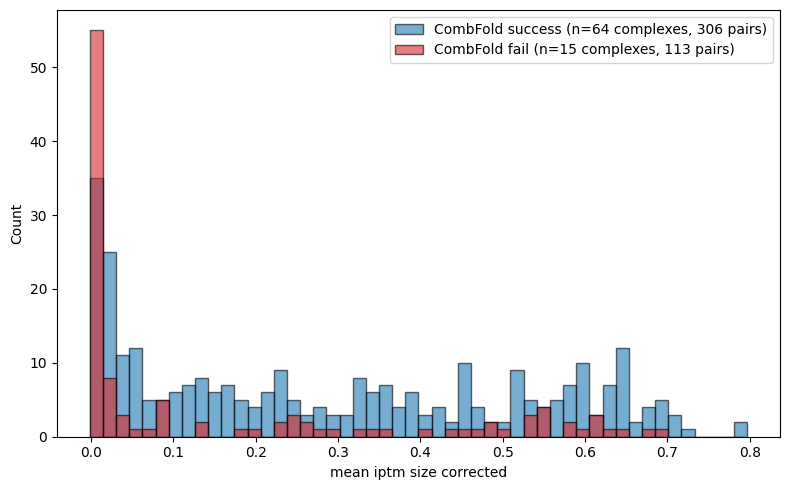

In [35]:
# Define shared bins so both histograms align
import numpy as np
success = no_homodimer_with_iptm.filter(pl.col("combfold_successfully") == True)
fail = no_homodimer_with_iptm.filter(pl.col("combfold_successfully") == False)

n_complexes_s = success["comb_fold_submission"].n_unique()
n_pairs_s = success.height
n_complexes_f = fail["comb_fold_submission"].n_unique()
n_pairs_f = fail.height


all_vals = no_homodimer_with_iptm["chain_pair_iptm_mean_corrected"].to_list()
bins = np.linspace(min(all_vals), max(all_vals), 51)

plt.figure(figsize=(8, 5))
plt.hist(success["chain_pair_iptm_mean_corrected"].to_list(), bins=bins, alpha=0.6,
         label=f"CombFold success (n={n_complexes_s} complexes, {n_pairs_s} pairs)", color="tab:blue", edgecolor="black")
plt.hist(fail["chain_pair_iptm_mean_corrected"].to_list(), bins=bins, alpha=0.6,
         label=f"CombFold fail (n={n_complexes_f} complexes, {n_pairs_f} pairs)", color="tab:red", edgecolor="black")
plt.xlabel("mean iptm size corrected")
plt.ylabel("Count")
#plt.title("iptm (mean corrected) by CombFold outcome")
plt.legend()
plt.tight_layout()
plt.show()

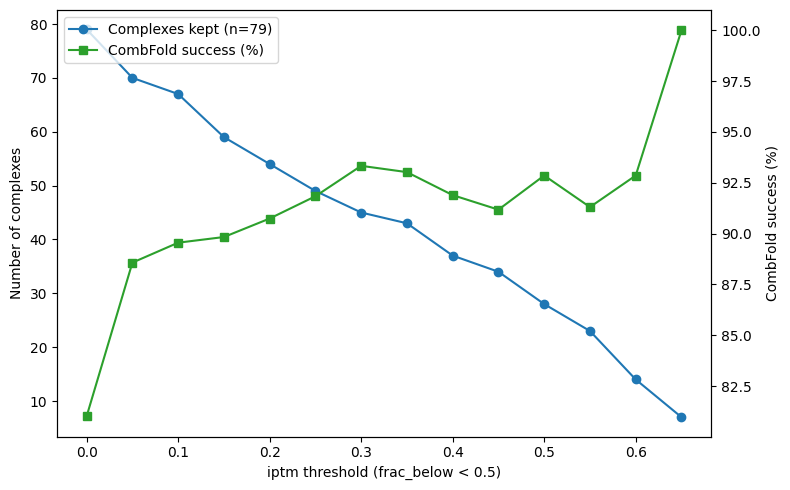

In [31]:
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.0, 0.7, 0.05)

n_total_complexes = no_homodimer_with_iptm["#Complex ac"].n_unique()

n_kept = []
pct_success = []

for t in thresholds:
    complex_stats = (
        no_homodimer_with_iptm
        .group_by(["comb_fold_submission", "#Complex ac", "combfold_successfully"])
        .agg([
            pl.col("chain_pair_iptm_mean_corrected").count().alias("n_pairs"),
            (pl.col("chain_pair_iptm_mean_corrected") < t).sum().alias("n_below"),
        ])
        .with_columns(
            (pl.col("n_below") / pl.col("n_pairs")).alias("frac_below")
        )
        .filter(pl.col("frac_below") < 0.5)
    )

    n = complex_stats.height
    n_kept.append(n)
    n_s = complex_stats.filter(pl.col("combfold_successfully") == True).height
    pct_success.append(100 * n_s / n if n > 0 else 0)

n_at_0 = n_kept[0]
pct_min = min(pct_success)
pct_max = max(pct_success)
pad = max(1, (pct_max - pct_min) * 0.05)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(thresholds, n_kept, marker="o", color="tab:blue", label=f"Complexes kept (n={n_at_0})")
ax1.set_xlabel("iptm threshold (frac_below < 0.5)")
ax1.set_ylabel("Number of complexes", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(thresholds, pct_success, marker="s", color="tab:green", label="CombFold success (%)")
ax2.set_ylabel("CombFold success (%)", color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(pct_min - pad, pct_max + pad)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

#plt.title("Complexes retained >= 50 % ")
fig.tight_layout()
plt.show()

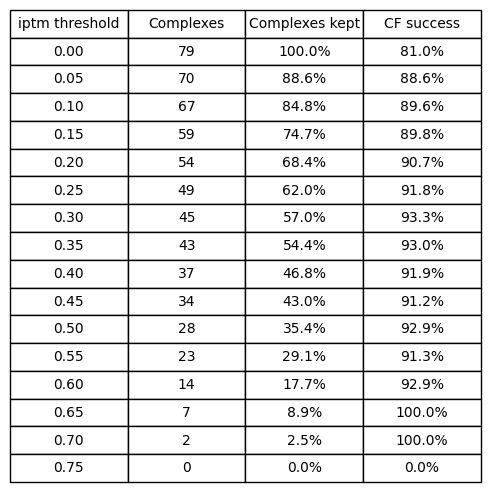

In [32]:
import numpy as np
import matplotlib.pyplot as plt

n_total = no_homodimer_with_iptm["#Complex ac"].n_unique()

thresholds = [round(t, 2) for t in np.arange(0.0, 0.76, 0.05)]

rows = []
for t in thresholds:
    complex_stats = (
        no_homodimer_with_iptm
        .group_by(["comb_fold_submission", "#Complex ac", "combfold_successfully"])
        .agg([
            pl.col("chain_pair_iptm_mean_corrected").count().alias("n_pairs"),
            (pl.col("chain_pair_iptm_mean_corrected") < t).sum().alias("n_below"),
        ])
        .with_columns(
            (pl.col("n_below") / pl.col("n_pairs")).alias("frac_below")
        )
        .filter(pl.col("frac_below") < 0.5)
    )
    n = complex_stats.height
    n_s = complex_stats.filter(pl.col("combfold_successfully") == True).height
    pct = round(100 * n_s / n, 1) if n > 0 else 0
    pct_kept = round(100 * n / n_total, 1)
    rows.append([f"{t:.2f}", str(n), f"{pct_kept:.1f}%", f"{pct:.1f}%"])

fig, ax = plt.subplots(figsize=(5, 5))
ax.axis("off")

col_labels = ["iptm threshold", "Complexes", "Complexes kept", "CF success"]
table = ax.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)


plt.tight_layout()
plt.show()

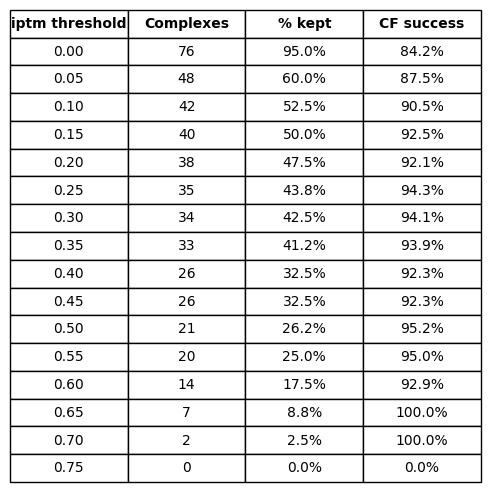

In [ ]:

n_total = no_homodimer_with_iptm["#Complex ac"].n_unique()

thresholds = [round(t, 2) for t in np.arange(0.0, 0.76, 0.05)]

rows = []
for t in thresholds:
    complex_stats = (
        no_homodimer_with_iptm
        .group_by(["comb_fold_submission", "#Complex ac", "combfold_successfully"])
        .agg([
            pl.col("chain_pair_iptm_mean_corrected").count().alias("n_pairs"),
            (pl.col("chain_pair_iptm_mean_corrected") < t).sum().alias("n_below"),
        ])
        # Keep only if NO pair is below threshold (n_below == 0)
        .filter(pl.col("n_below") == 0)
    )
    n = complex_stats.height
    n_s = complex_stats.filter(pl.col("combfold_successfully") == True).height
    pct = round(100 * n_s / n, 1) if n > 0 else 0
    pct_kept = round(100 * n / n_total, 1)
    rows.append([f"{t:.2f}", str(n), f"{pct_kept:.1f}%", f"{pct:.1f}%"])

fig, ax = plt.subplots(figsize=(5, 5))
ax.axis("off")

col_labels = ["iptm threshold", "Complexes", "% kept", "CF success"]
table = ax.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold")

plt.tight_layout()
plt.show()

how many of these complexes have a corresponding pdb file

In [4]:
pdb_dir = Path(
    data_dir/ "Complex_pdb_files/identity"
)

filenames = [p.name for p in pdb_dir.glob("*.pdb")]

identity_pdb = (
    pl.DataFrame({"filename": filenames})
    .with_columns(
        pl.col("filename").str.replace(".pdb", "").alias("stem")
    )
    .with_columns(
        pl.col("stem").str.split("_").list.get(0).alias("Complex_ac"),
        pl.col("stem").str.split("_").list.get(1).alias("uniprot_id"),
    )
    .select(["Complex_ac", "uniprot_id"])
)

identity_pdb.write_csv(data_dir / "Complex_pdb_files/identity/identity_pdb_Complex_ac_mapping.csv")

In [11]:
mapped_ids = identity_pdb["Complex_ac"].to_list() 
third_setup_results = third_setup_results.with_columns(
    pdb_file = pl.col("#Complex ac").is_in(mapped_ids)
)

In [ ]:
third_setup_results

other stuff

In [14]:
# Find complexes where fewer than 50% of pairs have iptm < 0.1
complex_frac = (
    no_homodimer_with_iptm
    .group_by("comb_fold_submission")
    .agg([
        pl.col("chain_pair_iptm_mean_corrected").count().alias("n_pairs"),
        (pl.col("chain_pair_iptm_mean_corrected") < 0.1).sum().alias("n_below_01"),
    ])
    .with_columns(
        (pl.col("n_below_01") / pl.col("n_pairs")).alias("frac_below_01")
    )
    .filter(pl.col("frac_below_01") < 0.5)
    .select("comb_fold_submission")
)

filtered_more_iptm = no_homodimer_with_iptm.join(complex_frac, on="comb_fold_submission", how="inner")

print(f"Before: {no_homodimer_with_iptm['comb_fold_submission'].n_unique()} complexes, {no_homodimer_with_iptm.height} pairs")
print(f"After: {filtered_more_iptm['comb_fold_submission'].n_unique()} complexes, {filtered_more_iptm.height} pairs")

Before: 80 complexes, 464 pairs
After: 67 complexes, 290 pairs


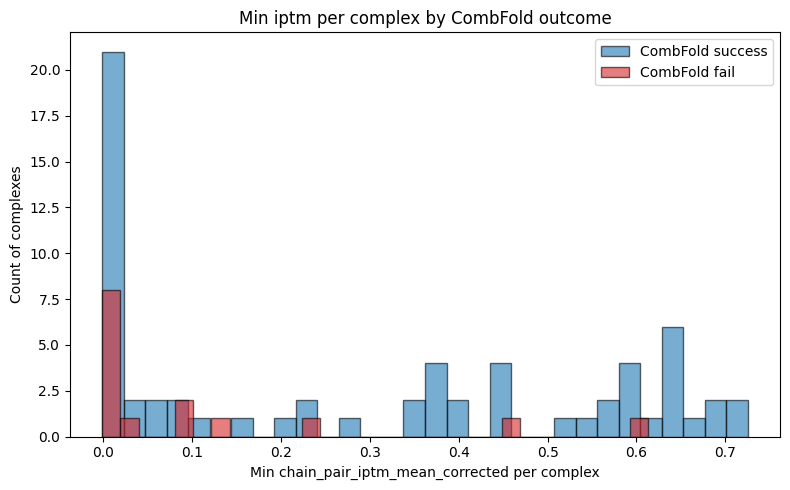

In [11]:
# Min iptm per complex, split by success/fail
min_success = success.group_by("comb_fold_submission").agg(
    pl.col("chain_pair_iptm_mean_corrected").min().alias("min_iptm")
)
min_fail = fail.group_by("comb_fold_submission").agg(
    pl.col("chain_pair_iptm_mean_corrected").min().alias("min_iptm")
)

plt.figure(figsize=(8, 5))
plt.hist(min_success["min_iptm"].to_list(), bins=30, alpha=0.6, label="CombFold success", color="tab:blue", edgecolor="black")
plt.hist(min_fail["min_iptm"].to_list(), bins=30, alpha=0.6, label="CombFold fail", color="tab:red", edgecolor="black")
plt.xlabel("Min chain_pair_iptm_mean_corrected per complex")
plt.ylabel("Count of complexes")
plt.title("Min iptm per complex by CombFold outcome")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
no_homodimer_third_setup_results.write_csv("no_homodimer_third_setup_results")

## How many proteins do i have in complex, yeast map and combined

In [ ]:
YM_COMPLEX_overlap = pl.read_csv(
    data_dir / "Complex_Portal/YeastMap/complex_db_complete_unique_overlap_complex_yeastmap_by_complex.csv"
)
complex_db_entries = pl.read_csv(
    data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv",
    separator="	",
)

homodimer_with_pdb = pl.read_csv(
    data_dir / "Pipeline/homodimer_pdb_files/merged_pdbs/pdb_file_names.csv"
)

In [ ]:
YM_proteins = set(
    YM_COMPLEX_overlap["predicted_complex"].str.split(" ").explode().unique().to_list()
)

col = "Identifiers (and stoichiometry) of molecules in complex"
complex_proteins = set(
    complex_db_entries
    .select(
        pl.col(col).str.replace_all(r"[\[\]]", "")
        .str.replace_all(r"\|", ",")
        .str.split(",")
    )
    .explode(col)
    .with_columns(
        pl.col(col).str.replace_all(r"\(\d+\)", "").str.strip_chars()
    )
    .filter(~pl.col(col).str.starts_with("CHEBI:"))
    .filter(pl.col(col) != "")
    .filter(~pl.col(col).str.contains("CPX"))
    .get_column(col)
    .unique()
    .to_list()
)

homodimer_set = set(homodimer_with_pdb["uniprot_id_homodimer"].to_list())

# --- Table ---
def fmt(n_hom, total):
    return f"{n_hom} ({n_hom / total * 100:.1f}%)"

YM_n = len(YM_proteins)
YM_hom = len(YM_proteins & homodimer_set)

CP_n = len(complex_proteins)
CP_hom = len(complex_proteins & homodimer_set)

ALL_n = len(YM_proteins | complex_proteins)
ALL_hom = len((YM_proteins | complex_proteins) & homodimer_set)

table = pl.DataFrame({
    "Source": ["YeastMap", "Complex Portal", "Combined"],
    "Unique proteins": [str(YM_n), str(CP_n), str(ALL_n)],
    "PDB homodimer present": [fmt(YM_hom, YM_n), fmt(CP_hom, CP_n), fmt(ALL_hom, ALL_n)],
})

table

In [ ]:
import matplotlib.pyplot as plt

YM_n  = len(YM_proteins);      YM_hom  = len(YM_proteins & homodimer_set)
CP_n  = len(complex_proteins); CP_hom  = len(complex_proteins & homodimer_set)
ALL_n = len(YM_proteins | complex_proteins)
ALL_hom = len((YM_proteins | complex_proteins) & homodimer_set)

def fmt(n_hom, total):
    return f"{n_hom} ({n_hom / total * 100:.1f}%)"

fig, ax = plt.subplots(figsize=(8, 2.4))
ax.axis("off")

cell_text = [
    ["YeastMap",        f"{YM_n:,}",  fmt(YM_hom, YM_n)],
    ["Complex Portal",  f"{CP_n:,}",  fmt(CP_hom, CP_n)],
    ["Combined",        f"{ALL_n:,}", fmt(ALL_hom, ALL_n)],
]
col_labels = ["Source", "Unique proteins", "PDB homodimer present"]

tbl = ax.table(
    cellText=cell_text, colLabels=col_labels,
    cellLoc="center", loc="center",
    colWidths=[0.30, 0.30, 0.40],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1.0, 2.0)

# Header
for j in range(3):
    c = tbl[0, j]
    c.set_facecolor("cornflowerblue")
    c.set_text_props(color="white")
    c.set_edgecolor("white"); c.set_linewidth(1.5)

# Body
for i in range(1, 4):
    for j in range(3):
        c = tbl[i, j]
        c.set_facecolor("#FAF9F3" if i % 2 == 1 else "white")
        c.set_edgecolor("#ECE9E2"); c.set_linewidth(1.0)

# First column left-aligned + bold
for i in range(1, 4):
    tbl[i, 0].set_text_props(ha="left")

# Highlight Combined row
for j in range(3):
    c = tbl[3, j]
    c.set_facecolor("#ECE9E2")


plt.tight_layout()
#plt.savefig("protein_homodimer_table.png", dpi=250, bbox_inches="tight",
           # facecolor="white", pad_inches=0.15)
plt.show()

## other stuff

In [ ]:
yeastmap_complex_pairs_with_scores = pl.read_csv("./Dataframes/Yeast_Map/yeastmap_complex_pairs_with_scores_incl_db.csv")
complex_by_breaking_values = pl.read_csv("./Dataframes/Yeast_Map/complex_by_breaking_values.csv")
YM_pred = pl.read_csv(data_dir_YM / "yeast.MAP_complexes_wConfidenceScores_wGenenames_total779_20251214.csv")
complex_db_entries = pl.read_csv(data_dir / "Complex_Portal/Saccharomyces cerevisiae_ComplexTab.tsv", separator= "\t" )


In [ ]:
YM_pred_with_index = (
    YM_pred.with_row_index("predicted_complex_id", offset = 1)
    .with_columns(
        pl.format("CPX_{}", pl.col("predicted_complex_id")).alias("predicted_complex_id"))
    .rename({"UniProt_ACCs": "predicted_complex"})
)

shoudk have 168 complexes with high confidence scores, for how many of them do I have a complex on COMPLEX (so complete overlap) for how many of the, do i have a stoichioemtry, for how many of them do I have a structure? what is theor iptm score

In [ ]:
pred_high_confidence_list = (YM_pred_with_index.filter(pl.col("ComplexConfidence") == 1).get_column("predicted_complex_id").unique().to_list())

In [ ]:
high_confidence_complex_by_breaking_values = complex_by_breaking_values.filter(pl.col("predicted_complex_id").is_in(pred_high_confidence_list))

In [ ]:
high_confidence_complex_by_breaking_values.height

## Do i have the nexessary AF data to run CF?

In [ ]:
pairs = pl.read_parquet(
    get_data_dir() / "25.12_pooled-ppi-yeast/data-26.03/summary_pairs.parquet"
) #takes around 1 min to load, as confirmed by jürgen the files from 26.04 also do dont contain the self pairs


In [ ]:
self_pairs = pairs.filter(pl.col("af3_id1") == pl.col("af3_id2"))
print(f"Total self-pairs: {self_pairs.height}")
